In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
import os
print(os.getcwd())

d:\Mutual_Fund_Project\notebooks


In [5]:
import pandas as pd

nav = pd.read_csv("../Data/raw/02_nav_history.csv")

performance = pd.read_csv("../Data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../Data/raw/10_benchmark_indices.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [7]:
print("NAV Columns:")
print(nav.columns.tolist())

print("\nPerformance Columns:")
print(performance.columns.tolist())

print("\nBenchmark Columns:")
print(benchmark.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']

Performance Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Benchmark Columns:
['date', 'index_name', 'close_value']


In [8]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [9]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [10]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [11]:
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

print("Date conversion completed")

Date conversion completed


In [12]:
nav = nav.sort_values(
    by=['amfi_code', 'date']
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [13]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [14]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [15]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

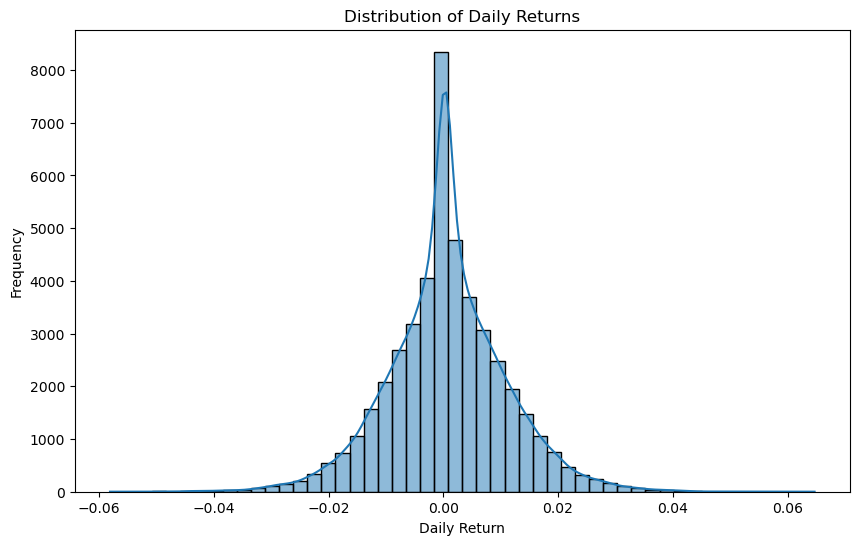

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

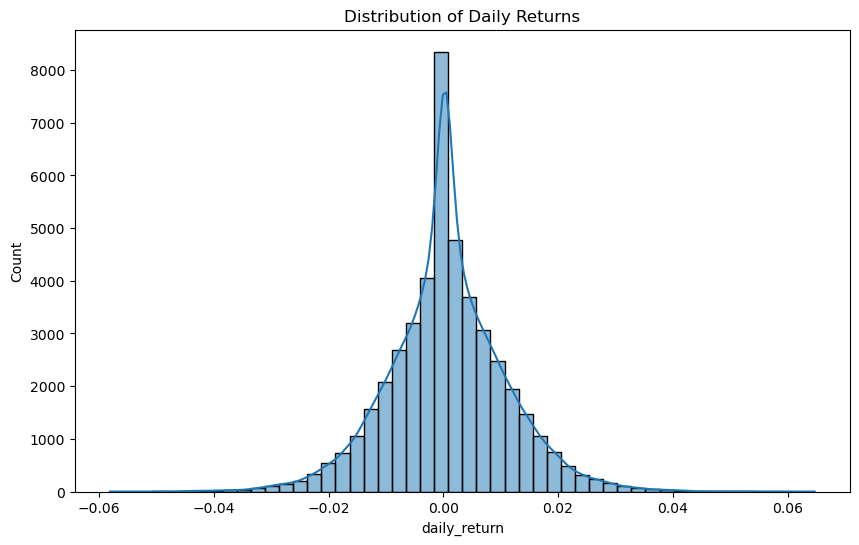

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.savefig(
    "../reports/daily_return_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [18]:
print(nav['date'].min())
print(nav['date'].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [19]:
cagr = nav.groupby('amfi_code').agg(
    start_date=('date', 'min'),
    end_date=('date', 'max'),
    start_nav=('nav', 'first'),
    end_nav=('nav', 'last')
).reset_index()

cagr.head()

,amfi_code,start_date,end_date,start_nav,end_nav
0,100016,2022-01-03,2026-05-29,520.4608,583.6113
1,100025,2022-01-03,2026-05-29,26.3169,31.8843
2,100033,2022-01-03,2026-05-29,107.3758,342.0072
3,101206,2022-01-03,2026-05-29,305.0996,773.2939
4,101207,2022-01-03,2026-05-29,38.5736,53.9836


In [21]:
cagr['years'] = (
    (cagr['end_date'] - cagr['start_date']).dt.days
) / 365.25

cagr.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726


In [22]:
cagr['CAGR'] = (
    (cagr['end_nav'] / cagr['start_nav'])
    ** (1 / cagr['years'])
) - 1

cagr.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,CAGR
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388


In [23]:
cagr['CAGR_%'] = cagr['CAGR'] * 100

cagr[['amfi_code', 'CAGR_%']].head()

,amfi_code,CAGR_%
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [24]:
cagr = cagr.merge(
    performance[['amfi_code', 'scheme_name', 'fund_house']],
    on='amfi_code',
    how='left'
)

cagr.head()

,amfi_code,start_date,end_date,start_nav,end_nav,years,CAGR,CAGR_%,scheme_name,fund_house
0,100016,2022-01-03,2026-05-29,520.4608,583.6113,4.399726,0.026371,2.637074,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,2022-01-03,2026-05-29,26.3169,31.8843,4.399726,0.044582,4.458210,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,2022-01-03,2026-05-29,305.0996,773.2939,4.399726,0.235384,23.538361,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,2022-01-03,2026-05-29,38.5736,53.9836,4.399726,0.079388,7.938765,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [25]:
cagr = cagr.sort_values(
    by='CAGR_%',
    ascending=False
)

cagr.head(10)

,amfi_code,start_date,end_date,start_nav,end_nav,years,CAGR,CAGR_%,scheme_name,fund_house
25,120505,2022-01-03,2026-05-29,135.8720,473.7640,4.399726,0.328274,32.827406,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
21,119598,2022-01-03,2026-05-29,89.8738,309.2050,4.399726,0.324235,32.423536,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,2022-01-03,2026-05-29,81.6814,279.7511,4.399726,0.322874,32.287440,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
36,148569,2022-01-03,2026-05-29,28.8620,97.7435,4.399726,0.319495,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
34,148567,2022-01-03,2026-05-29,70.2514,230.2708,4.399726,0.309741,30.974108,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,2022-01-03,2026-05-29,49.9131,163.2397,4.399726,0.309075,30.907455,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,100033,2022-01-03,2026-05-29,107.3758,342.0072,4.399726,0.301232,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
38,149323,2022-01-03,2026-05-29,78.4622,245.3651,4.399726,0.295811,29.581087,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
16,119094,2022-01-03,2026-05-29,68.3023,203.8581,4.399726,0.282144,28.214417,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
19,119551,2022-01-03,2026-05-29,54.3856,149.3216,4.399726,0.258047,25.804686,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


In [26]:
cagr.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

print("CAGR table saved successfully")

CAGR table saved successfully


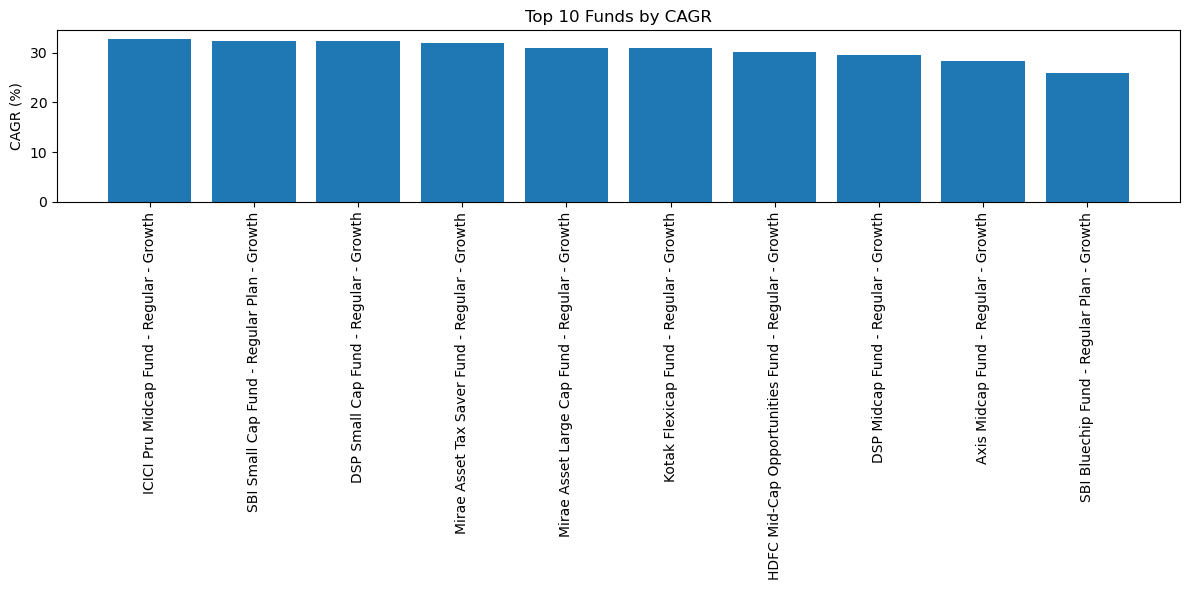

In [27]:
top10 = cagr.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['CAGR_%']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by CAGR")

plt.ylabel("CAGR (%)")

plt.tight_layout()

plt.show()

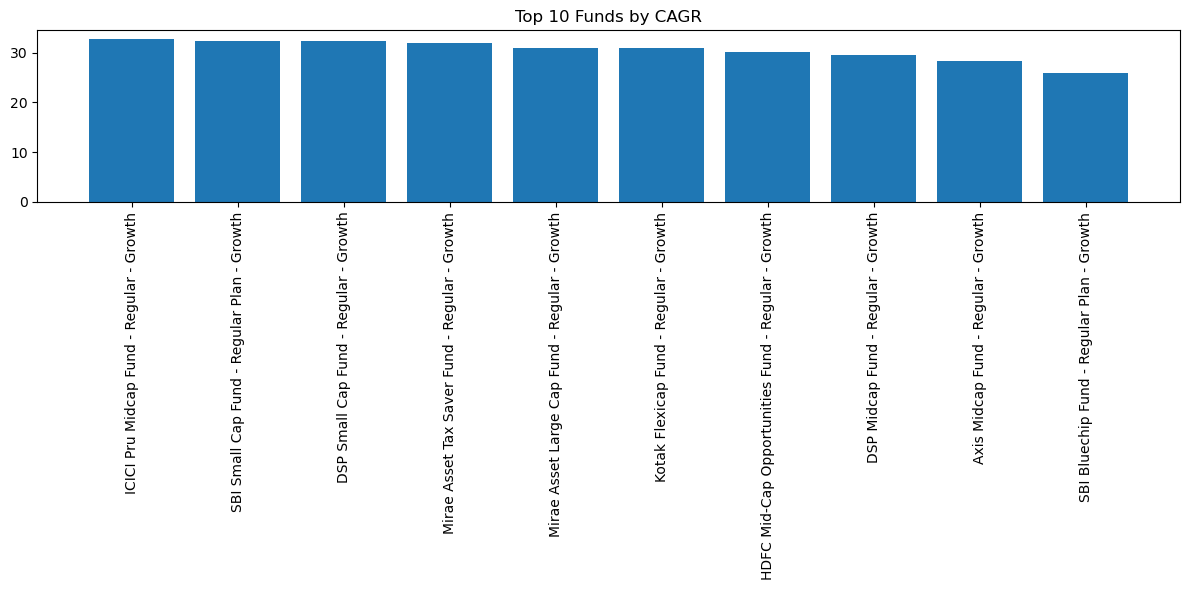

In [28]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['CAGR_%']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by CAGR")

plt.tight_layout()

plt.savefig(
    "../reports/cagr_top10.png",
    bbox_inches="tight"
)

plt.show()

In [29]:
mean_return = (
    nav.groupby('amfi_code')['daily_return']
       .mean()
       * 252
)

mean_return.head()

amfi_code
100016    0.035683
100025    0.042854
100033    0.272111
101206    0.214647
101207    0.106962
Name: daily_return, dtype: float64

In [30]:
std_return = (
    nav.groupby('amfi_code')['daily_return']
       .std()
       * np.sqrt(252)
)

std_return.head()

amfi_code
100016    0.145481
100025    0.039052
100033    0.189367
101206    0.145682
101207    0.257973
Name: daily_return, dtype: float64

In [31]:
risk_free_rate = 0.065

sharpe = pd.DataFrame({
    'Annual_Return': mean_return,
    'Annual_Std': std_return
})

sharpe['Sharpe_Ratio'] = (
    (sharpe['Annual_Return'] - risk_free_rate)
    / sharpe['Annual_Std']
)

sharpe.head()

,Annual_Return,Annual_Std,Sharpe_Ratio
amfi_code,,,
100016,0.035683,0.145481,-0.201517
100025,0.042854,0.039052,-0.567095
100033,0.272111,0.189367,1.093699
101206,0.214647,0.145682,1.027213
101207,0.106962,0.257973,0.162661


In [32]:
sharpe = sharpe.reset_index()

sharpe = sharpe.merge(
    performance[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

sharpe.head()

,amfi_code,Annual_Return,Annual_Std,Sharpe_Ratio,scheme_name
0,100016,0.035683,0.145481,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042854,0.039052,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.272111,0.189367,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.214647,0.145682,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.106962,0.257973,0.162661,ABSL Small Cap Fund - Regular - Growth


In [33]:
sharpe = sharpe.sort_values(
    by='Sharpe_Ratio',
    ascending=False
)

sharpe.head(10)

,amfi_code,Annual_Return,Annual_Std,Sharpe_Ratio,scheme_name
34,148567,0.270566,0.141937,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.272602,0.158870,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.283262,0.176740,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.231033,0.137414,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.292653,0.192909,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.265908,0.177462,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,0.272111,0.189367,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.218037,0.141484,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.214647,0.145682,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.212448,0.143638,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [34]:
sharpe.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio CSV Saved")

Sharpe Ratio CSV Saved


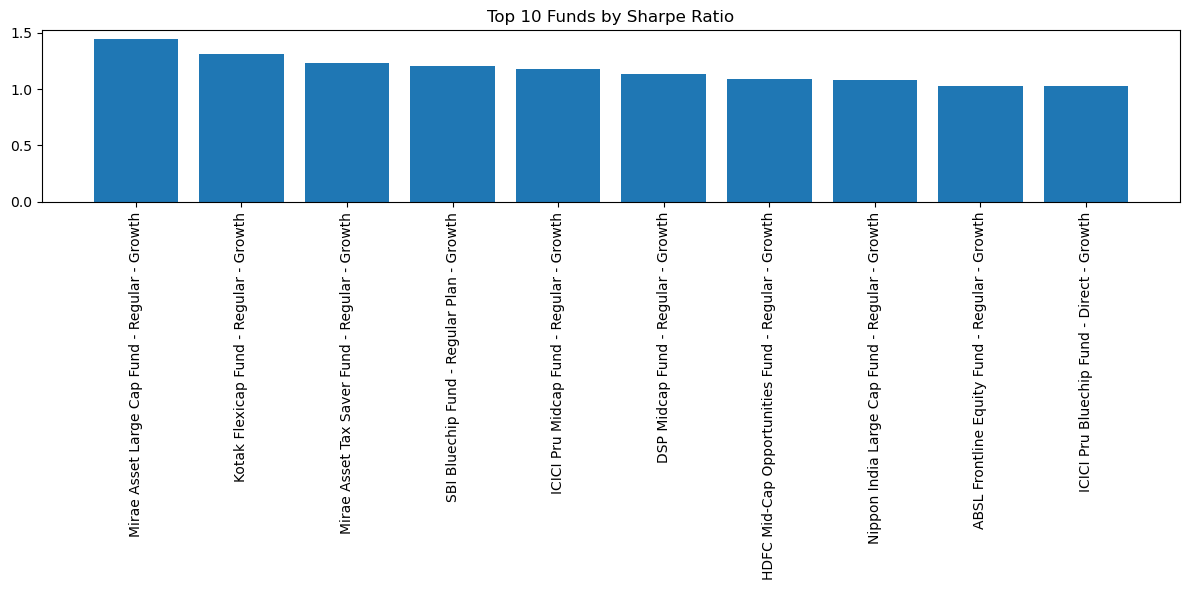

In [35]:
top10 = sharpe.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['Sharpe_Ratio']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.show()

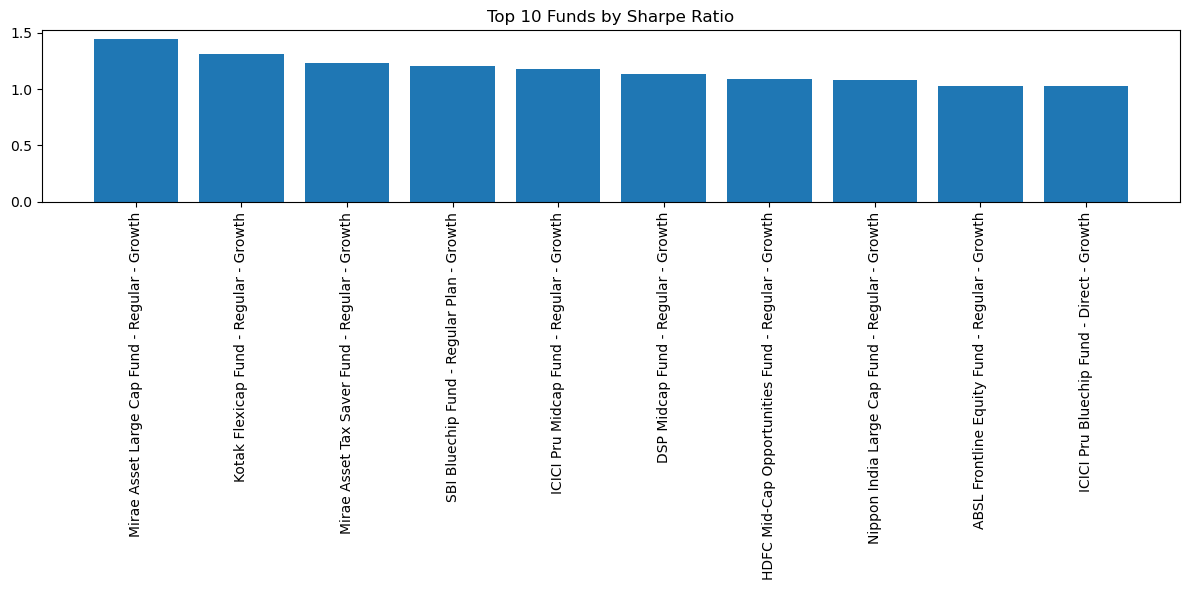

In [36]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['Sharpe_Ratio']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
downside_returns = nav.copy()

downside_returns['downside_return'] = downside_returns['daily_return']

downside_returns.loc[
    downside_returns['downside_return'] > 0,
    'downside_return'
] = np.nan

downside_returns.head()

,amfi_code,date,nav,daily_return,downside_return
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,-0.001210


In [38]:
downside_std = (
    downside_returns.groupby('amfi_code')['downside_return']
    .std()
    * np.sqrt(252)
)

downside_std.head()

amfi_code
100016    0.083513
100025    0.023539
100033    0.113229
101206    0.083157
101207    0.151786
Name: downside_return, dtype: float64

In [39]:
sortino = pd.DataFrame({
    'Annual_Return': mean_return,
    'Downside_Std': downside_std
})

sortino['Sortino_Ratio'] = (
    (sortino['Annual_Return'] - risk_free_rate)
    / sortino['Downside_Std']
)

sortino.head()

,Annual_Return,Downside_Std,Sortino_Ratio
amfi_code,,,
100016,0.035683,0.083513,-0.351047
100025,0.042854,0.023539,-0.940851
100033,0.272111,0.113229,1.829134
101206,0.214647,0.083157,1.799563
101207,0.106962,0.151786,0.276456


In [40]:
sortino = sortino.reset_index()

sortino = sortino.merge(
    performance[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

sortino.head()

,amfi_code,Annual_Return,Downside_Std,Sortino_Ratio,scheme_name
0,100016,0.035683,0.083513,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042854,0.023539,-0.940851,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.272111,0.113229,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.214647,0.083157,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.106962,0.151786,0.276456,ABSL Small Cap Fund - Regular - Growth


In [41]:
sortino = sortino.sort_values(
    by='Sortino_Ratio',
    ascending=False
)

sortino.head(10)

,amfi_code,Annual_Return,Downside_Std,Sortino_Ratio,scheme_name
34,148567,0.270566,0.086168,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.272602,0.087806,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,0.283262,0.101663,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.231033,0.077576,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.292653,0.112180,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.265908,0.107145,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,0.218037,0.082717,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,0.272111,0.113229,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,0.212448,0.081675,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,0.214647,0.083157,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [42]:
sortino.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio CSV Saved")

Sortino Ratio CSV Saved


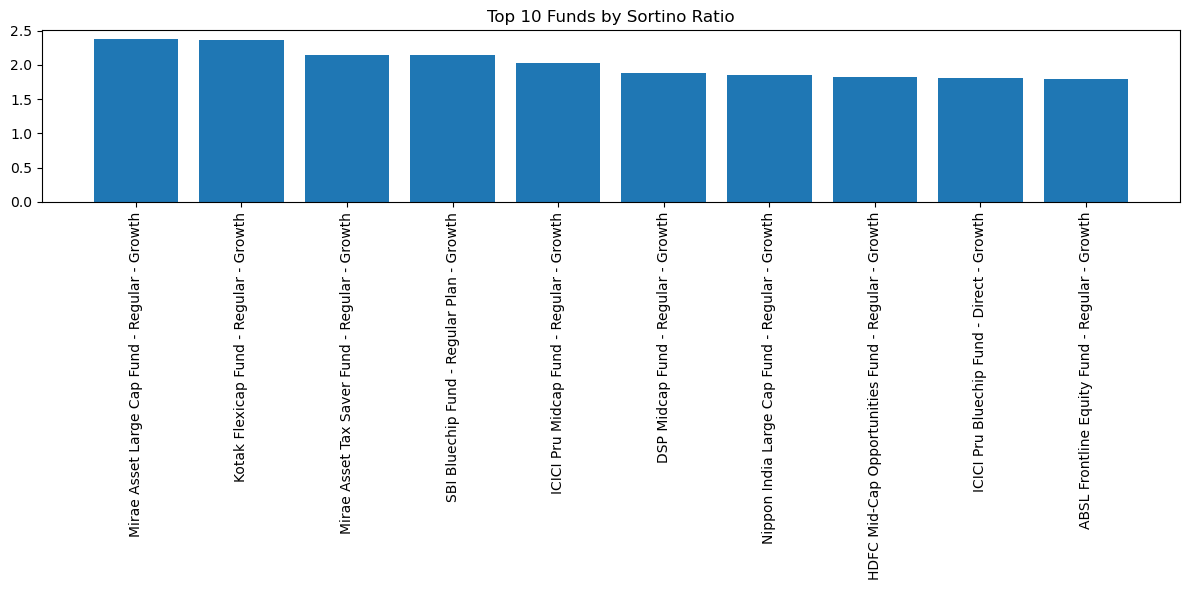

In [43]:
top10 = sortino.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['Sortino_Ratio']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.show()

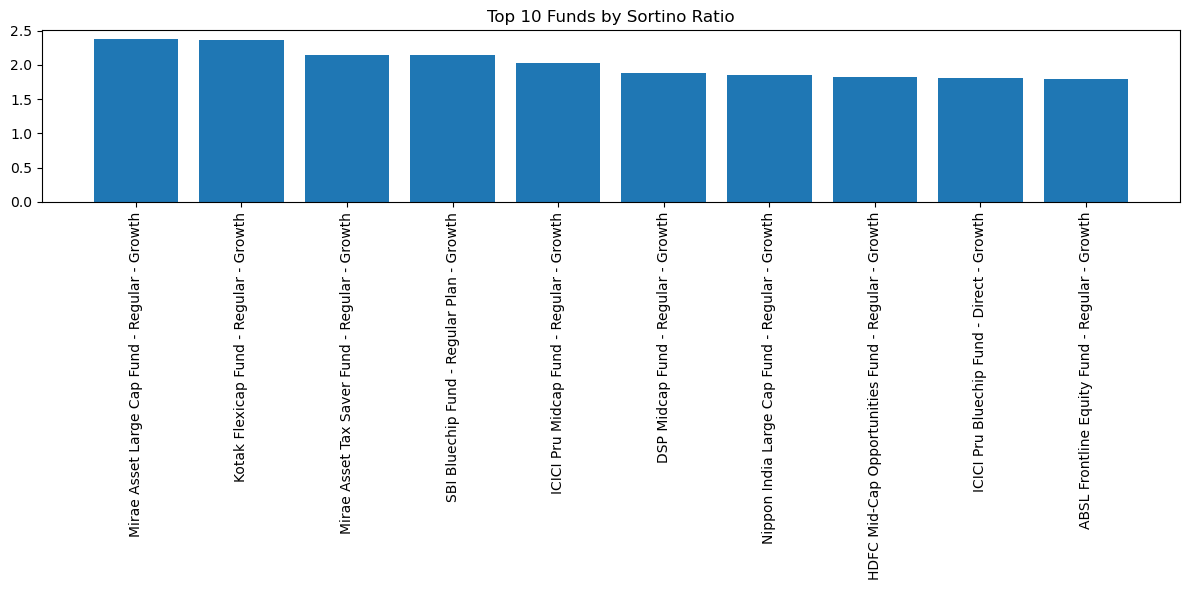

In [44]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['Sortino_Ratio']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio.png",
    bbox_inches="tight"
)

plt.show()

In [45]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [47]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [48]:
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [49]:
merged = pd.merge(
    nav[['amfi_code', 'date', 'daily_return']],
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

merged.head()

,amfi_code,date,daily_return,benchmark_return
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,-0.013540
2,100016,2022-01-05,0.012865,0.004003
3,100016,2022-01-06,-0.011377,-0.002935
4,100016,2022-01-07,-0.001210,0.006150


In [50]:
from scipy.stats import linregress

results = []

for fund in merged['amfi_code'].unique():

    temp = merged[
        merged['amfi_code'] == fund
    ].dropna()

    if len(temp) > 30:

        slope, intercept, r, p, std = linregress(
            temp['benchmark_return'],
            temp['daily_return']
        )

        results.append([
            fund,
            intercept * 252,
            slope
        ])

In [51]:
alpha_beta = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [52]:
alpha_beta = alpha_beta.merge(
    performance[
        ['amfi_code', 'scheme_name']
    ],
    on='amfi_code',
    how='left'
)

alpha_beta.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [53]:
alpha_beta = alpha_beta.sort_values(
    by='alpha',
    ascending=False
)

alpha_beta.head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth


In [54]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta CSV Saved Successfully")

Alpha Beta CSV Saved Successfully


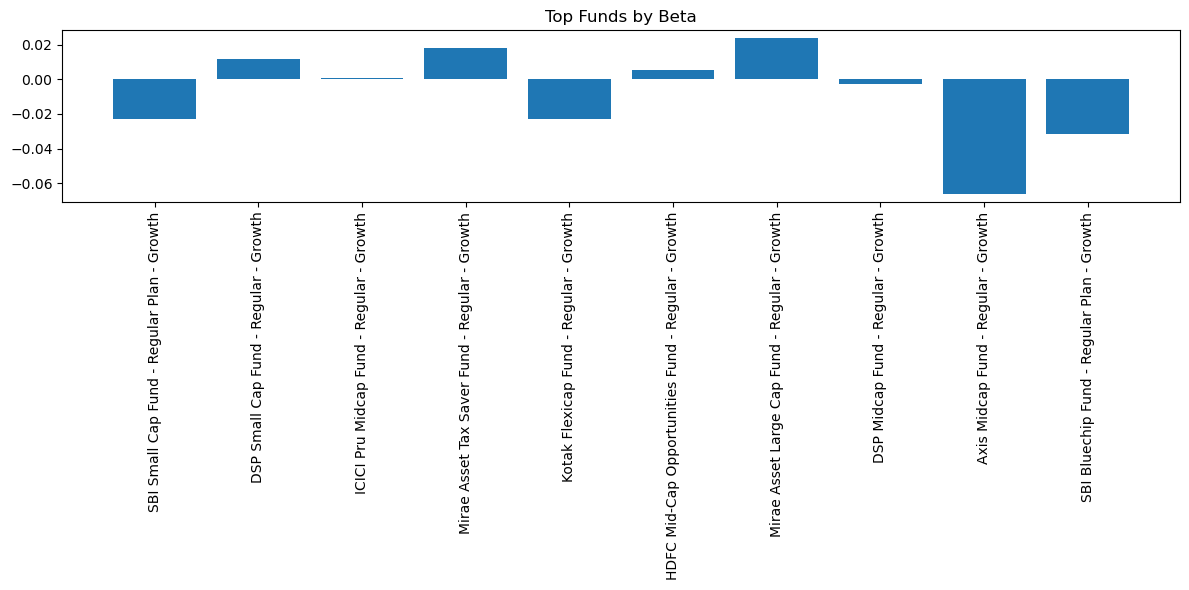

In [55]:
top10 = alpha_beta.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['beta']
)

plt.xticks(rotation=90)

plt.title("Top Funds by Beta")

plt.tight_layout()

plt.show()

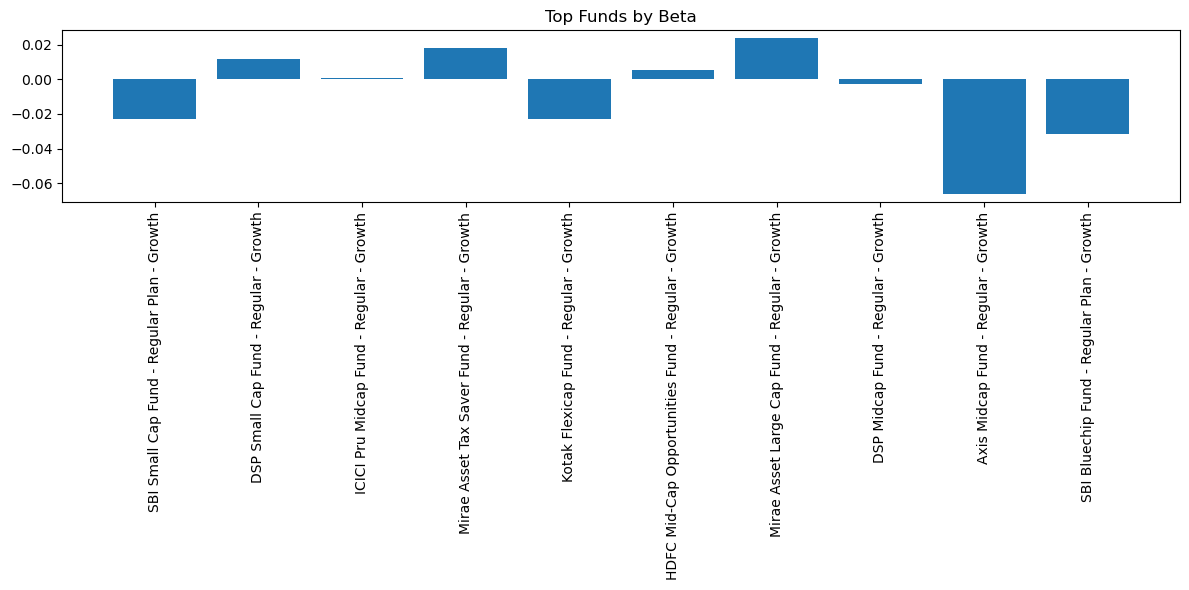

In [56]:
plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['beta']
)

plt.xticks(rotation=90)

plt.title("Top Funds by Beta")

plt.tight_layout()

plt.savefig(
    "../reports/beta_chart.png",
    bbox_inches="tight"
)

plt.show()

In [57]:
nav = nav.sort_values(['amfi_code', 'date'])

nav['running_max'] = nav.groupby('amfi_code')['nav'].cummax()

nav.head()

,amfi_code,date,nav,daily_return,running_max
5750,100016,2022-01-03,520.4608,NaN,520.4608
5751,100016,2022-01-04,515.0971,-0.010306,520.4608
5752,100016,2022-01-05,521.7239,0.012865,521.7239
5753,100016,2022-01-06,515.7880,-0.011377,521.7239
5754,100016,2022-01-07,515.1639,-0.001210,521.7239


In [58]:
nav['drawdown'] = (
    nav['nav'] / nav['running_max']
) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [59]:
max_dd = nav.groupby('amfi_code').agg(
    max_drawdown=('drawdown', 'min')
).reset_index()

max_dd.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [60]:
max_dd = max_dd.merge(
    performance[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

max_dd.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [61]:
max_dd.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Saved")

Maximum Drawdown Saved


In [62]:
scorecard = performance.copy()

scorecard['return_rank'] = scorecard['return_3yr_pct'].rank(ascending=False)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)

scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)

scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)

scorecard['drawdown_rank'] = scorecard['max_drawdown_pct'].rank(ascending=True)

In [63]:
scorecard['Fund_Score'] = (
    0.30 * scorecard['return_rank']
    + 0.25 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.15 * scorecard['expense_rank']
    + 0.10 * scorecard['drawdown_rank']
)

In [64]:
scorecard['Fund_Score'] = (
    100
    * (
        scorecard['Fund_Score']
        - scorecard['Fund_Score'].min()
    )
    / (
        scorecard['Fund_Score'].max()
        - scorecard['Fund_Score'].min()
    )
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14288,1.54,4,Moderate,26.0,26.5,32.0,30.5,19.5,79.639175
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1231,0.66,3,Moderate,34.0,35.5,9.0,4.0,12.0,55.541237
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,33.0,17.268041
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,2.0,19.5,22.5,5.5,11.0,0.000000
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,24101,0.77,5,Low,38.0,5.0,13.0,9.0,39.0,44.329897


In [65]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


In [66]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

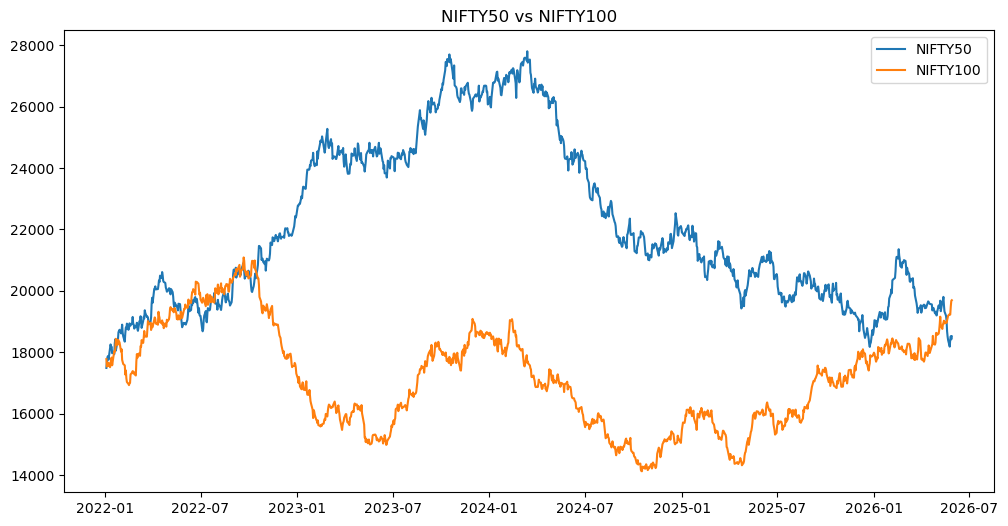

In [67]:
plt.figure(figsize=(12,6))

for idx in ['NIFTY50', 'NIFTY100']:

    temp = benchmark[
        benchmark['index_name'] == idx
    ]

    plt.plot(
        temp['date'],
        temp['close_value'],
        label=idx
    )

plt.legend()

plt.title("NIFTY50 vs NIFTY100")

plt.show()

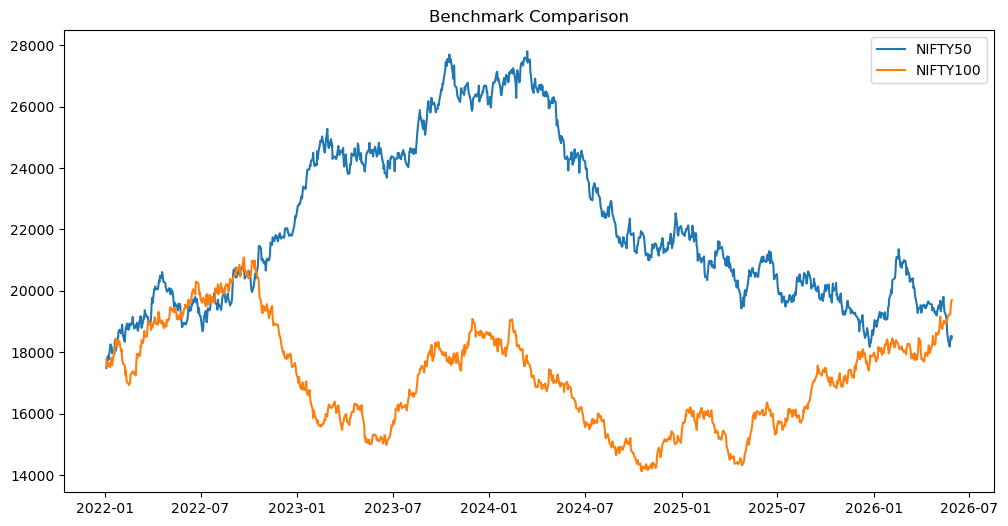

In [68]:
plt.figure(figsize=(12,6))

for idx in ['NIFTY50', 'NIFTY100']:

    temp = benchmark[
        benchmark['index_name'] == idx
    ]

    plt.plot(
        temp['date'],
        temp['close_value'],
        label=idx
    )

plt.legend()

plt.title("Benchmark Comparison")

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()